# Free Spoken Digit Dataset

**Metody ekstrakcji cech:**
1. MFFC
2. Ręczna ekstrakcja cech


In [27]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.signal import butter, filtfilt


RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

## Ładowanie danych
Pobieranie zbioru danych i ładowanie plików audio.
Parsujemy nazwę pliku, aby wyodrębnić etykietę.

In [28]:
path = kagglehub.dataset_download("joserzapata/free-spoken-digit-dataset-fsdd")
recordings_path = os.path.join(path, "recordings")

files = glob.glob(os.path.join(recordings_path, "*.wav"))

data = []
labels = []
max_len = 0

for f in files:
    filename = os.path.basename(f)
    digit = int(filename.split('_')[0])
    
    y, sr = librosa.load(f, sr=None)
    
    data.append(y)
    labels.append(digit)

    if len(y) > max_len:
        max_len = len(y)


print(f"Loaded {len(data)} files.")
print(f"Maximum audio length: {max_len} samples.")

Loaded 3000 files.
Maximum audio length: 18262 samples.


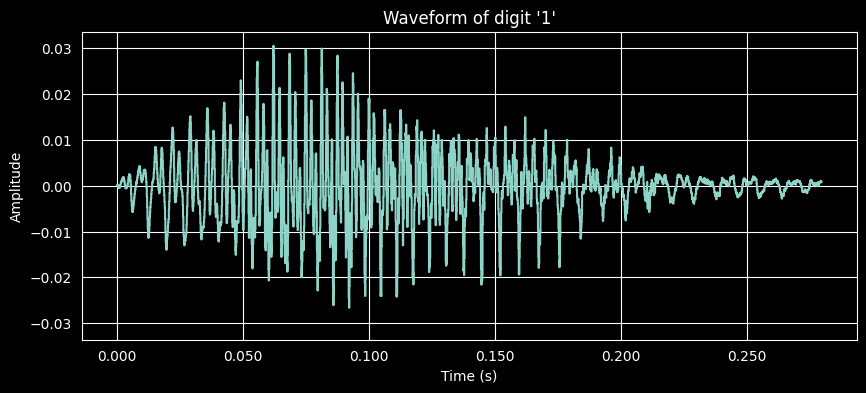

In [29]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(data[0], sr=8000)
plt.title(f"Waveform of digit '{labels[0]}'")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

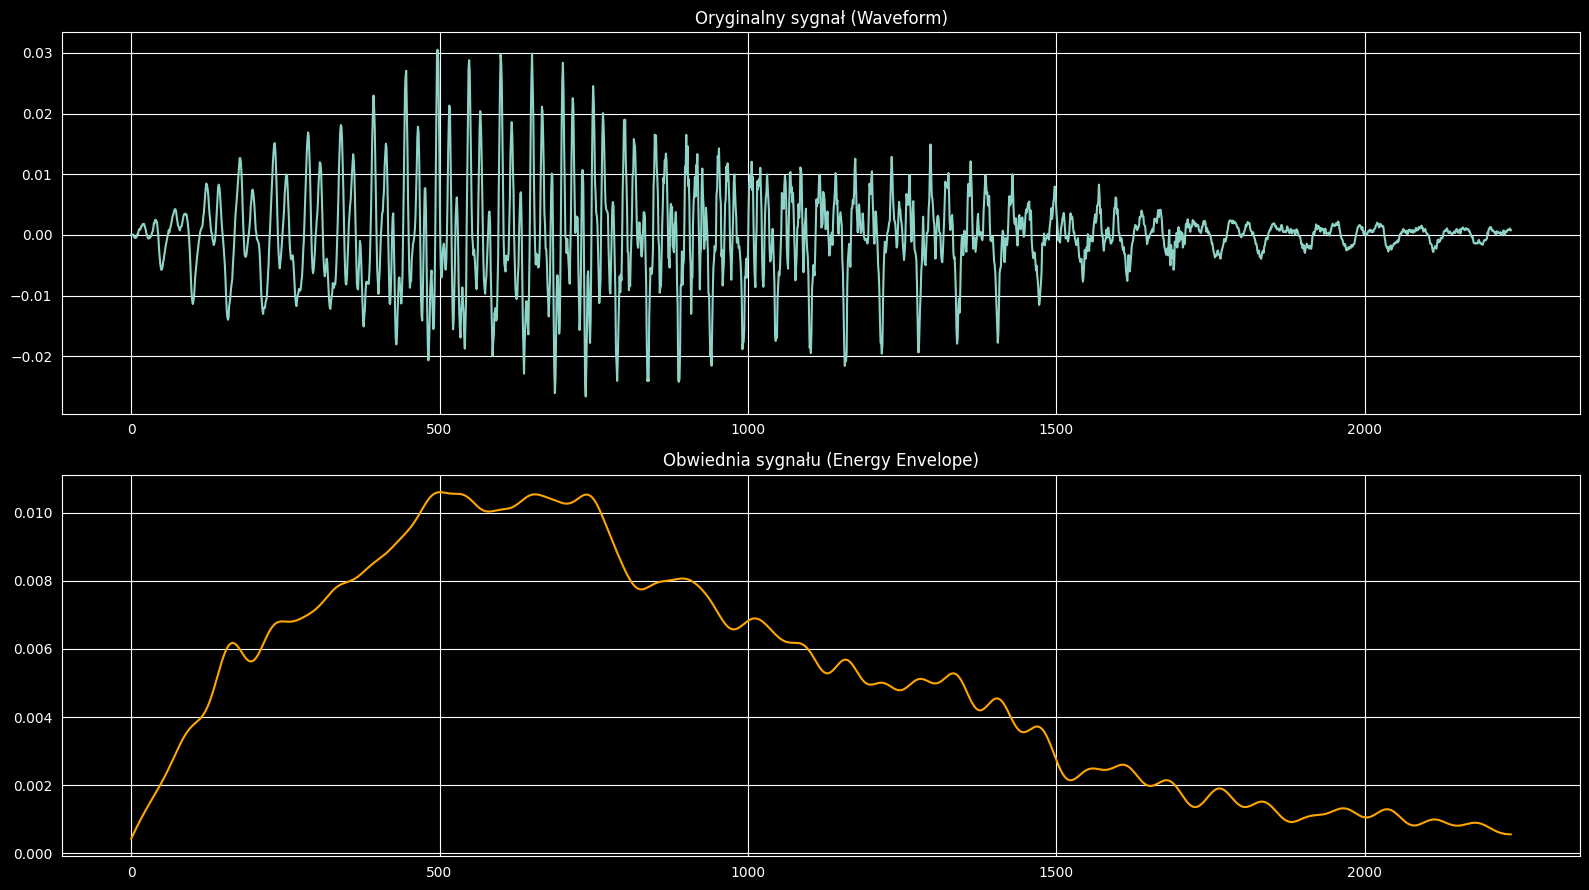

In [30]:
def apply_butter_filter(data, cutoff, fs, filter_type, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype=filter_type, analog=False)
    return filtfilt(b, a, data)

clean_signal = apply_butter_filter(data[0], 30, 8000, 'high')

rectified_signal = np.abs(clean_signal)

final_envelope = apply_butter_filter(rectified_signal, 100, 8000, 'low')

fig, axs = plt.subplots(2, 1, figsize=(16, 9))

axs[0].plot(data[0])
axs[0].set_title("Oryginalny sygnał (Waveform)")

axs[1].plot(final_envelope, color='orange')
axs[1].set_title("Obwiednia sygnału (Energy Envelope)")

plt.tight_layout()
plt.show()

In [31]:
from IPython.display import Audio, display

display(Audio(data[0], rate=8000))

In [32]:
from IPython.display import Audio, display

display(Audio(final_envelope, rate=8000))

## Metoda ekstrakcji cech 1: MFCC

In [33]:
def extract_features_mfcc(audio_data, sr=8000, n_mfcc=13):
    features = []
    for y in audio_data:
        n_fft = 2048
        if len(y) < n_fft:
            y = librosa.util.fix_length(y, size=n_fft)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft)

        mean = np.mean(mfcc, axis=1)
        std = np.std(mfcc, axis=1)
        feature_vector = np.concatenate((mean, std))
        features.append(feature_vector)
    return np.array(features)

In [34]:
X_mfcc = extract_features_mfcc(data)
y_labels = np.array(labels)
print(f"X_mfcc shape: {X_mfcc.shape}")

X_mfcc shape: (3000, 26)


In [35]:
pd.DataFrame(X_mfcc).describe()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,-271.877380,56.062481,6.076531,-1.543178,-28.243551,-17.941643,-20.445732,-11.609112,-16.959290,-6.305225,...,17.037182,15.110580,11.914168,10.352642,8.349723,7.561365,6.936310,6.645806,5.804389,6.115712
std,87.780937,35.747452,27.230684,22.675985,16.541147,17.521259,12.351480,14.603439,12.107623,8.206882,...,9.298454,6.615038,5.551341,4.676479,3.642461,3.403279,3.075402,3.108608,2.854924,3.066344
min,-544.709412,-41.570808,-71.954002,-82.993973,-80.340881,-79.098343,-64.554459,-52.053574,-59.984966,-33.801342,...,1.385803,1.100940,1.112185,0.738506,0.625280,0.686822,0.448507,0.417019,0.499666,0.608821
25%,-347.939857,36.300125,-13.984890,-16.050123,-39.737280,-30.246790,-28.170535,-22.527050,-22.390694,-11.108005,...,9.381500,10.130114,7.813765,7.008216,5.641984,5.048454,4.581474,4.319475,3.746189,3.814522
50%,-246.522247,58.282228,6.636971,0.322435,-29.863729,-17.753999,-20.719177,-12.343278,-14.621356,-5.448310,...,15.842439,14.656699,11.187124,9.759759,7.897497,7.122056,6.584606,6.210147,5.331876,5.563898
75%,-202.839897,77.219206,25.846253,13.720542,-16.897208,-4.923139,-11.629653,0.058024,-8.538089,-0.397833,...,23.392573,19.147336,15.286358,13.132624,10.674109,9.566870,8.893801,8.541010,7.453821,7.957837
max,-84.261238,191.390060,85.629044,63.861698,21.725361,32.407581,14.132863,26.507660,11.248414,17.465504,...,48.029167,41.366459,34.130669,30.733656,26.242788,23.720543,18.485561,19.625965,18.456301,19.052927


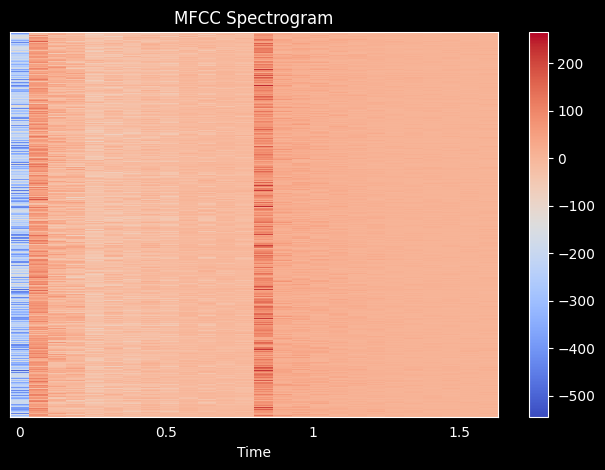

In [36]:
librosa.display.specshow(X_mfcc, sr=8000, x_axis='time')
plt.colorbar()
plt.title('MFCC Spectrogram')
plt.tight_layout()
plt.show()

## Metoda ekstrakcji cech 2: Ręczna ekstrakcja

In [42]:
def manual_features(signal, rate=8000, n_fft=2048):
    y = signal
    if len(y) < n_fft:
        y = librosa.util.fix_length(y, size=n_fft)

    zcr = librosa.feature.zero_crossing_rate(y=y,)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=rate, n_fft=n_fft)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=rate, n_fft=n_fft)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=rate, n_fft=n_fft)
    spec_cont = librosa.feature.spectral_contrast(y=y, sr=rate, n_fft=n_fft, n_bands=4)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=rate, n_fft=n_fft)
    rmse = librosa.feature.rms(y=y, frame_length=n_fft)

    return np.concatenate((
        zcr.mean(axis=1),
        rolloff.mean(axis=1),
        spec_cent.mean(axis=1),
        spec_bw.mean(axis=1),
        spec_cont.mean(axis=1),
        chroma_stft.mean(axis=1),
        rmse.mean(axis=1)
    ))

In [43]:
X_manual = np.array([manual_features(y) for y in data])
print(f"X_manual shape: {X_manual.shape}")
pd.DataFrame(X_manual).describe()

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


X_manual shape: (3000, 22)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.163221,2250.163343,1167.202689,966.633748,29.139386,18.899925,19.694146,17.529211,21.100417,0.317355,...,0.342328,0.370495,0.353744,0.337700,0.330117,0.359388,0.412960,0.449889,0.381021,0.039839
std,0.069416,576.315649,291.343862,159.479387,6.202872,4.155811,3.544965,2.830496,3.845933,0.195645,...,0.198074,0.206325,0.202196,0.198059,0.188232,0.182573,0.194508,0.203973,0.193308,0.027748
min,0.041406,863.281250,585.492046,396.452806,14.932829,9.269678,11.967976,9.128485,13.679153,0.008789,...,0.006014,0.006800,0.008845,0.012554,0.019025,0.015025,0.012113,0.010971,0.012964,0.001314
25%,0.112887,1829.124814,965.387180,856.824639,24.651741,15.440815,17.162877,15.365015,18.578318,0.154375,...,0.176606,0.200899,0.186364,0.167613,0.176150,0.214444,0.272866,0.302707,0.235668,0.011144
50%,0.147819,2265.625000,1111.491006,973.121463,27.687486,18.952558,19.291513,17.020645,20.578060,0.298578,...,0.318127,0.347022,0.328702,0.316491,0.307117,0.354577,0.406721,0.435740,0.365975,0.040503
75%,0.196309,2704.352679,1348.052035,1093.452118,33.265599,22.140534,21.974548,19.488738,23.013563,0.445719,...,0.483587,0.520488,0.498846,0.481850,0.460404,0.486299,0.548242,0.587719,0.506205,0.058241
max,0.451477,3475.260417,2226.571305,1369.924617,48.221590,31.880878,32.435038,29.263194,32.469208,1.000000,...,1.000000,1.000000,1.000000,0.981630,1.000000,0.998716,1.000000,1.000000,1.000000,0.145232


## Trenowanie modeli i porównanie

In [39]:
def train_and_evaluate(X, y, method_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

    models = {
        "SVM": SVC(),
        "RandomForest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier()
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f} for {method_name}")
    print()
    return results

results_mfcc = train_and_evaluate(X_mfcc, y_labels, "MFCC Features")
results_manual = train_and_evaluate(X_manual, y_labels, "Manual Features")


SVM Accuracy: 0.8467 for MFCC Features
RandomForest Accuracy: 0.9750 for MFCC Features
KNN Accuracy: 0.9467 for MFCC Features

SVM Accuracy: 0.3467 for Manual Features
RandomForest Accuracy: 0.8383 for Manual Features
KNN Accuracy: 0.4600 for Manual Features

